<h2><b>Clustering ( Unsupervised Learning )</b></h2>

<h4>In this the data is Grouped ,based on Similarity and Difference</h4>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib,os

In [2]:
df = pd.read_csv("farmer.csv")
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [3]:
df[df['label']=='pigeonpeas']

,N,P,K,temperature,humidity,ph,rainfall,label
400,3,72,24,36.512684,57.928872,6.031608,122.653969,pigeonpeas
401,40,59,23,36.891637,62.731782,5.269085,163.726655,pigeonpeas
402,33,73,23,29.235405,59.389676,5.985793,103.330180,pigeonpeas
403,27,57,24,27.335349,43.357960,6.091863,142.330368,pigeonpeas
404,10,79,18,21.064368,55.469859,5.624731,184.622671,pigeonpeas
...,...,...,...,...,...,...,...,...
495,35,71,17,29.892866,66.353751,6.931925,198.140300,pigeonpeas
496,11,72,22,29.377356,44.822946,6.842744,172.401680,pigeonpeas
497,20,60,22,29.650529,42.898332,6.876573,186.922605,pigeonpeas
498,10,71,18,19.542849,66.347773,6.151029,173.110698,pigeonpeas


In [37]:
df.label.nunique()

22

In [38]:
df.label.unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [6]:
group = df.groupby('label')

group[['K']].mean()

,K
label,
apple,199.89
banana,50.05
blackgram,19.24
chickpea,79.92
coconut,30.59
coffee,29.94
cotton,19.56
grapes,200.11
jute,39.99


In [7]:
nitrogen = group['N'].agg(min_nitro='min',max_nitro='max',avg_nitro='mean')

In [8]:
nitrogen.reset_index(inplace=True)

In [9]:
nitrogen

,label,min_nitro,max_nitro,avg_nitro
0,apple,0,40,20.80
1,banana,80,120,100.23
2,blackgram,20,60,40.02
3,chickpea,20,60,40.09
4,coconut,0,40,21.98
5,coffee,80,120,101.20
6,cotton,100,140,117.77
7,grapes,0,40,23.18
8,jute,60,100,78.40
9,kidneybeans,0,40,20.75


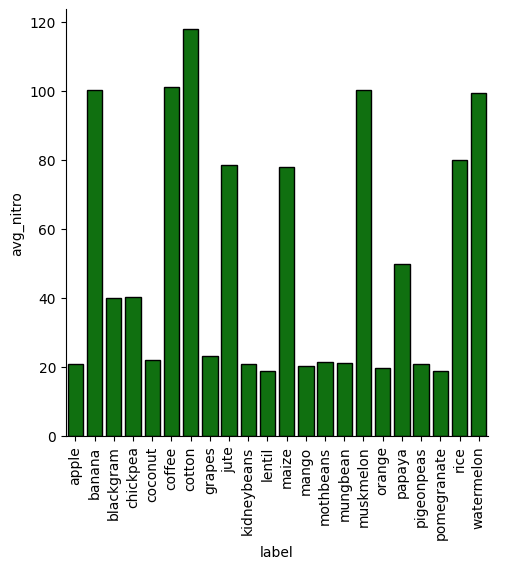

In [10]:
sns.catplot(x='label',y='avg_nitro',data=nitrogen,kind='bar',ec='k',color='g')
plt.xticks(rotation=90)
plt.show()

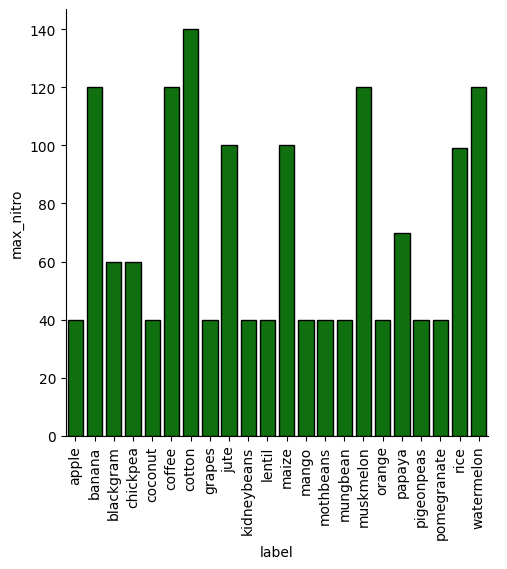

In [11]:
sns.catplot(x='label',y='max_nitro',data=nitrogen,kind='bar',ec='k',color='g')
plt.xticks(rotation=90)
plt.show()

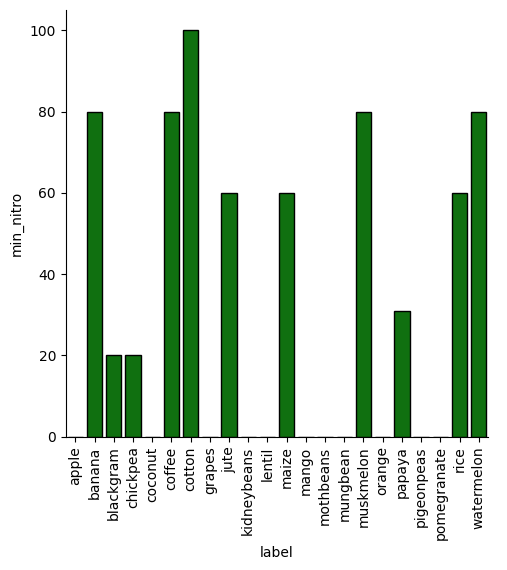

In [12]:
sns.catplot(x='label',y='min_nitro',data=nitrogen,kind='bar',ec='k',color='g')
plt.xticks(rotation=90)
plt.show()

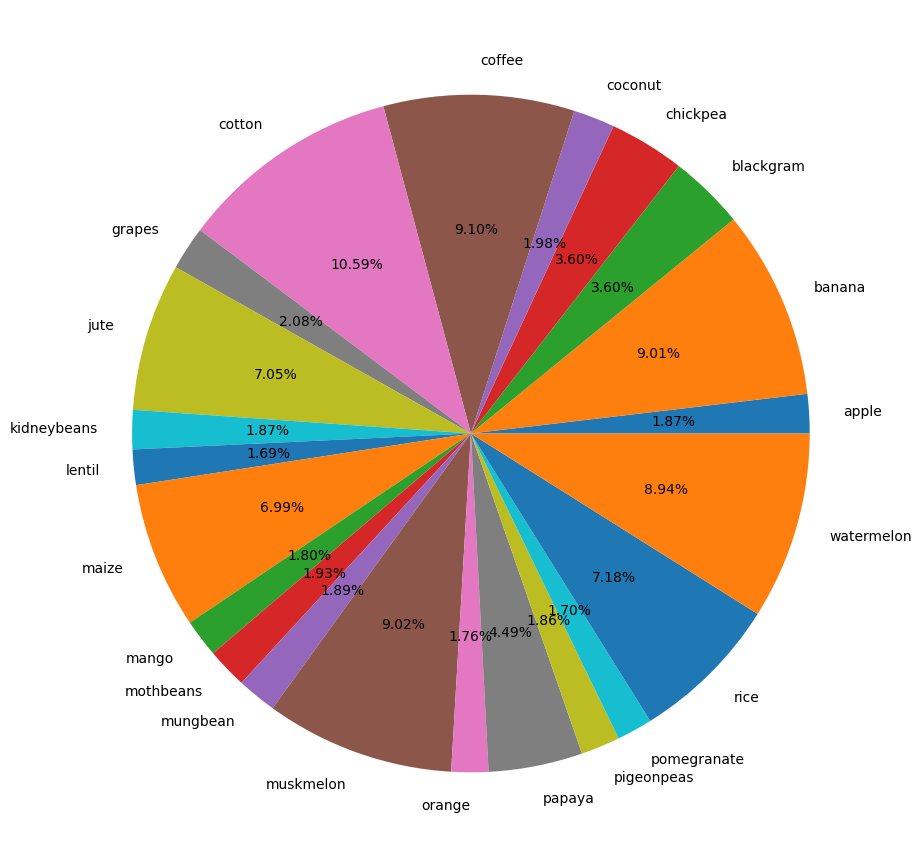

In [13]:
plt.figure(figsize=(11,11))
crops_label = list(nitrogen['label'])
avg_nitrogen = list(nitrogen['avg_nitro'])
plt.pie(avg_nitrogen,labels=crops_label,autopct='%2.2f%%')
plt.show()

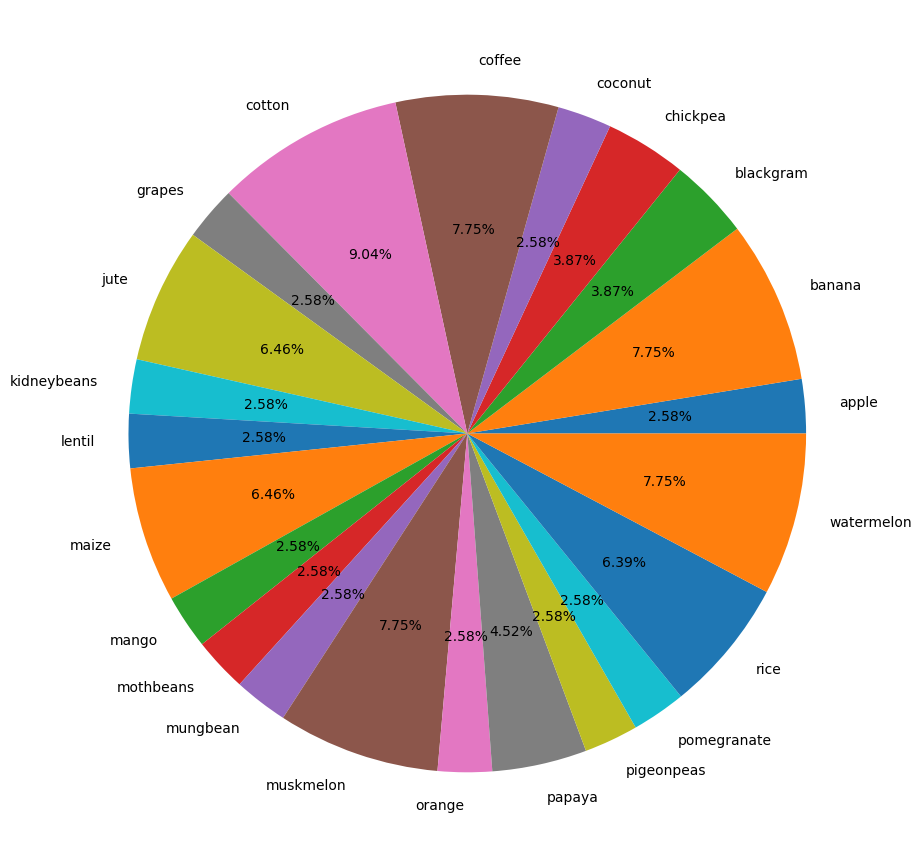

In [14]:
plt.figure(figsize=(11,11))
crops_label = list(nitrogen['label'])
max_nitrogen = list(nitrogen['max_nitro'])
plt.pie(max_nitrogen,labels=crops_label,autopct='%2.2f%%')
plt.show()

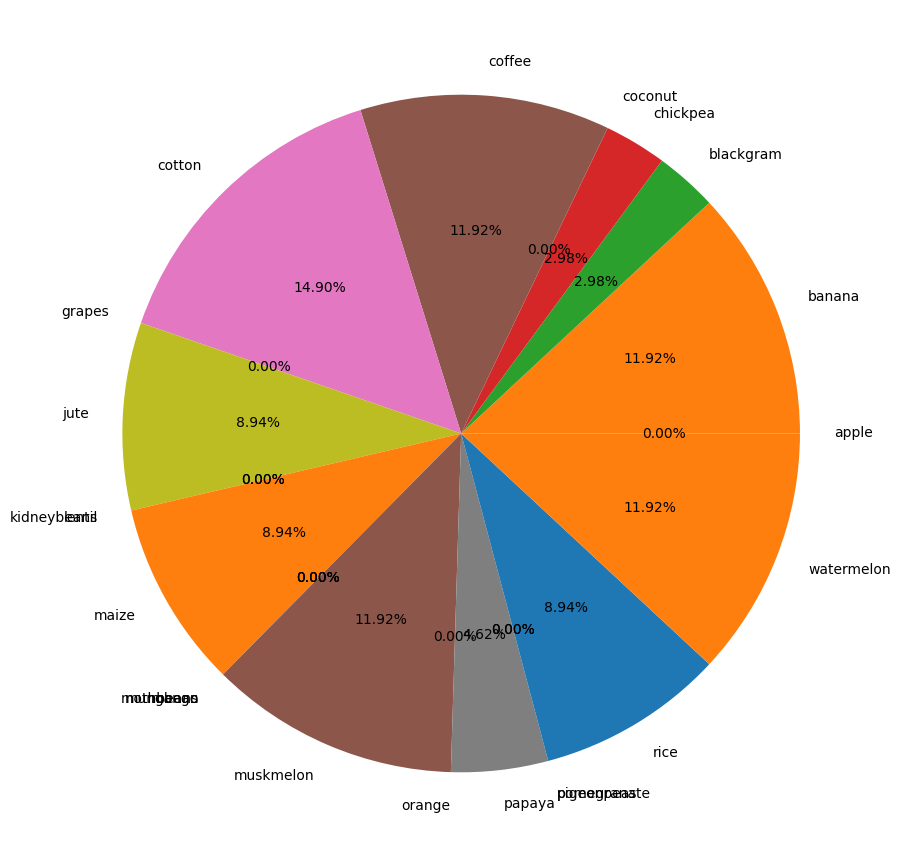

In [15]:
plt.figure(figsize=(11,11))
crops_label = list(nitrogen['label'])
min_nitrogen = list(nitrogen['min_nitro'])
plt.pie(min_nitrogen,labels=crops_label,autopct='%2.2f%%')
plt.show()

In [16]:
temp = group['temperature'].agg(min_temp='min',max_temp='max',avg_temp='mean')
temp.reset_index(inplace=True)

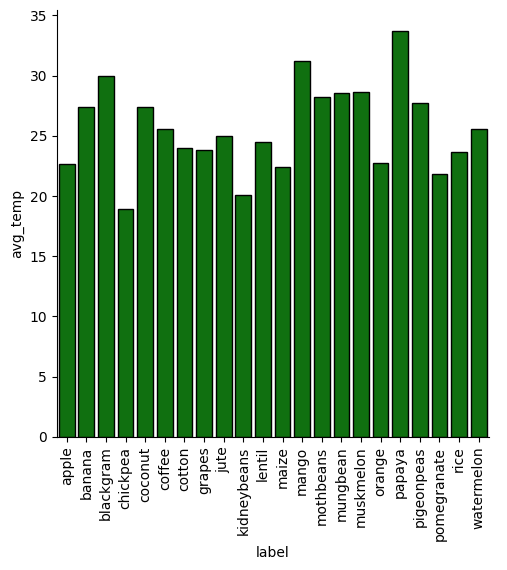

In [17]:
sns.catplot(x='label',y='avg_temp',data=temp,kind='bar',ec='k',color='g')
plt.xticks(rotation=90)
plt.show()

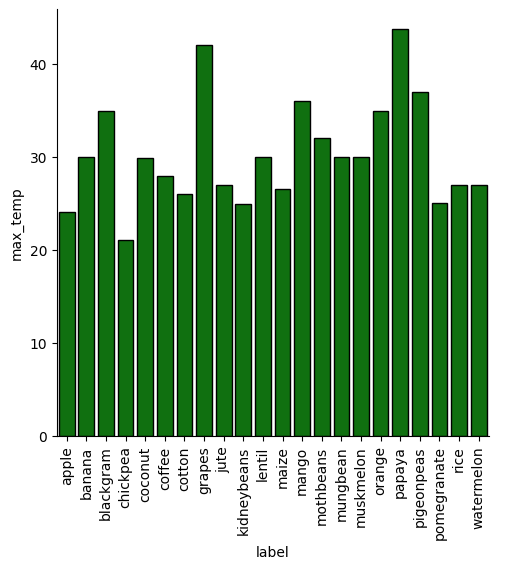

In [18]:
sns.catplot(x='label',y='max_temp',data=temp,kind='bar',ec='k',color='g')
plt.xticks(rotation=90)
plt.show()

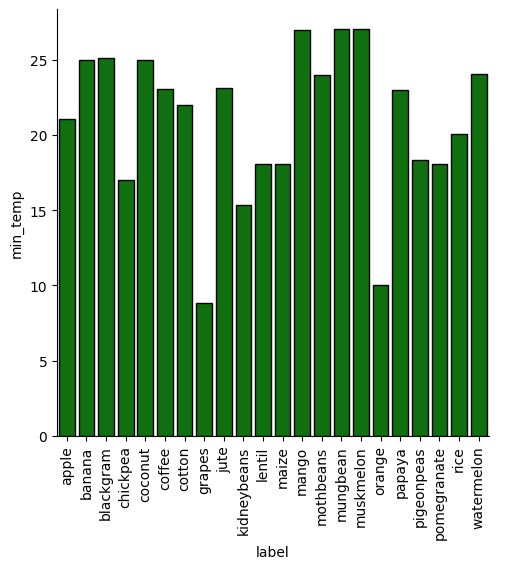

In [19]:
sns.catplot(x='label',y='min_temp',data=temp,kind='bar',ec='k',color='g')
plt.xticks(rotation=90)
plt.show()

In [20]:
rain = group['rainfall'].agg(min_rain='min',max_rain='max',avg_rain='mean')
rain.reset_index(inplace=True)

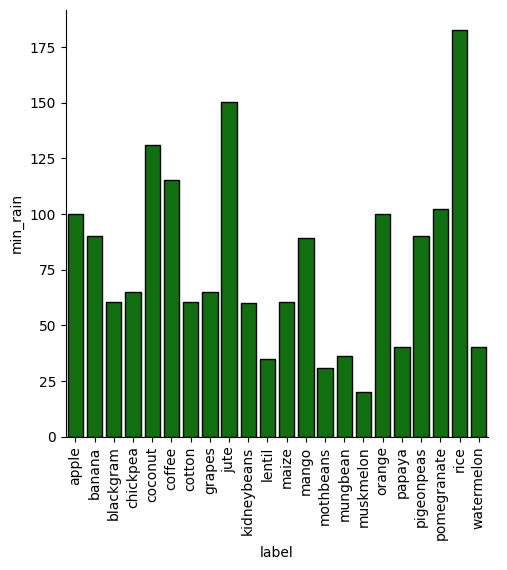

In [21]:
sns.catplot(x='label',y='min_rain',data=rain,kind='bar',ec='k',color='g')
plt.xticks(rotation=90)
plt.show()

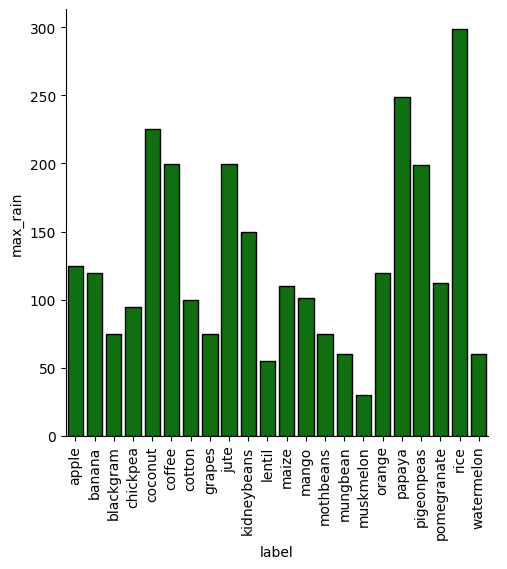

In [22]:
sns.catplot(x='label',y='max_rain',data=rain,kind='bar',ec='k',color='g')
plt.xticks(rotation=90)
plt.show()

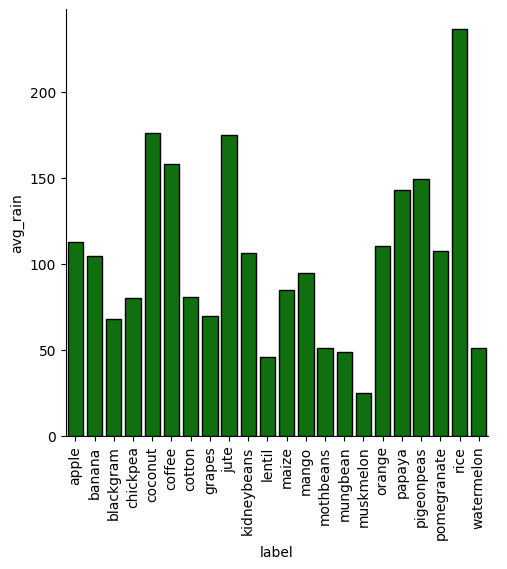

In [23]:
sns.catplot(x='label',y='avg_rain',data=rain,kind='bar',ec='k',color='g')
plt.xticks(rotation=90)
plt.show()

In [24]:
x = df.drop('label',axis=1)
x.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


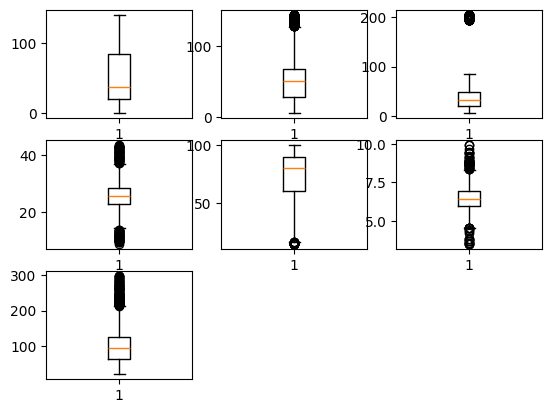

In [25]:
i = 1
for col in x.columns:
    plt.subplot(3,3,i)
    plt.boxplot(x[col])
    i+=1
plt.show()

In [26]:
# KMeansAlg ==> better accuracy --> normalize data

from sklearn.preprocessing import MinMaxScaler,RobustScaler,StandardScaler

std = StandardScaler()

x_transformed = std.fit_transform(x)

In [27]:
x_transformed

array([[ 1.0687974 , -0.34455075, -0.1016875 , ...,  0.47266646,
         0.04330173,  1.8103605 ],
       [ 0.93332887,  0.14061552, -0.14118477, ...,  0.39705125,
         0.73487256,  2.24205791],
       [ 0.25598625,  0.04964684, -0.08193887, ...,  0.48695381,
         1.77151047,  2.92106603],
       ...,
       [ 1.82742114, -0.61745677, -0.35841972, ..., -0.19123516,
        -0.13812031,  1.27141766],
       [ 1.80032743, -0.64777967, -0.27942519, ..., -0.86951801,
         0.37390383,  0.43154519],
       [ 1.44810927, -1.07230015, -0.35841972, ..., -0.49802006,
         0.40109573,  0.68200518]])

In [28]:
from sklearn.cluster import KMeans

# KMeans()
# Euclidian Distance Method

kmeans = KMeans() # default number clusters are 8 

kmeans.fit(x_transformed)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [29]:
kmeans.labels_

array([6, 6, 6, ..., 6, 1, 6], dtype=int32)

In [30]:
df['cluster_no'] = kmeans.labels_

In [31]:
group_seven = df[df['cluster_no'] == 7]
group_seven['label'].unique()

array(['maize', 'lentil', 'pomegranate', 'orange', 'coconut'],
      dtype=object)

In [32]:
os.makedirs('models',exist_ok=True)
joblib.dump(kmeans,"models/kmeans_model.lb")
joblib.dump(std,"models/standardscaler.lb")

['models/standardscaler.lb']

In [33]:
from sklearn.metrics import silhouette_score
# ranges from -1 to 1

silhouette_score(x_transformed,kmeans.labels_)

# Hirarchichal
# DBSCAN
# WCSS
# Elbow Method

0.325282192458758

In [34]:
df[['label','cluster_no']].to_csv('./models/filtering_data.csv',index=False)

In [35]:
df[df['cluster_no']==0]

,N,P,K,temperature,humidity,ph,rainfall,label,cluster_no
101,61,44,17,26.100184,71.574769,6.931757,102.266244,maize,0
112,62,52,16,22.275267,58.840159,6.967058,63.870206,maize,0
411,16,56,17,33.800200,40.032624,7.445445,176.616589,pigeonpeas,0
413,16,80,20,31.240217,56.673691,7.339321,122.014673,pigeonpeas,0
433,27,71,23,23.453790,46.487148,7.109598,150.871220,pigeonpeas,0
...,...,...,...,...,...,...,...,...,...
1767,45,58,49,30.107734,90.345464,6.827813,75.245220,papaya,0
1776,50,60,47,32.577207,92.748895,6.927918,93.794285,papaya,0
1781,32,55,51,29.607188,93.156428,6.573980,62.687105,papaya,0
1788,38,61,52,31.227901,94.940214,6.620730,46.442791,papaya,0
